epoch: 0 loss: 0.5113210082054138 val_loss: 0.5896449685096741
epoch: 50 loss: 0.0001277904666494578 val_loss: 8.570867066737264e-05
epoch: 100 loss: 0.0017582621658220887 val_loss: 7.593734335387126e-05
epoch: 150 loss: 0.0003570281551219523 val_loss: 6.472387758549303e-05
epoch: 200 loss: 0.002623931970447302 val_loss: 9.82571600616211e-06
epoch: 250 loss: 5.7700322940945625e-05 val_loss: 1.7851547227110132e-06
epoch: 300 loss: 0.0005388762219808996 val_loss: 5.318769399309531e-05
epoch: 350 loss: 2.4519977159798145e-05 val_loss: 4.599966359819518e-06
epoch: 400 loss: 1.21243165267515e-05 val_loss: 1.8492297613192932e-06
epoch: 450 loss: 0.0012703347019851208 val_loss: 0.00010276972170686349
best model is at epoch: 428 with validation loss: 1.1175869474300271e-07


[]

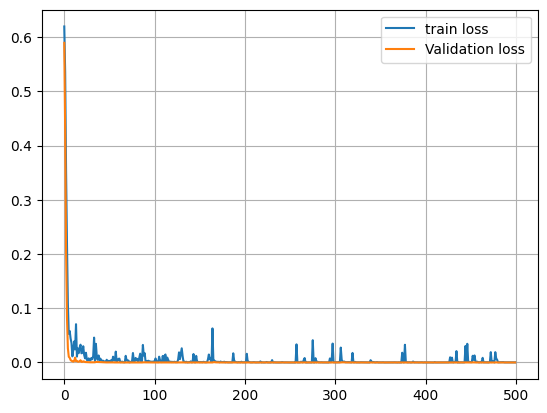

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import math
import matplotlib.pyplot as plt

def make_rings(n=200,inner_radius=1.0,outer_radius=3.0,noise=0.3):
  theta0=torch.rand(n)*2*math.pi
  r0=inner_radius+torch.rand(n)*noise
  c0=torch.stack([r0*torch.cos(theta0),r0*torch.sin(theta0)],dim=1)

  theta1=torch.rand(n)*2*math.pi
  r1=outer_radius+torch.rand(n)*noise
  c1=torch.stack([r1*torch.cos(theta1),r1*torch.sin(theta1)],dim=1)

  x=torch.cat([c0,c1],dim=0)
  y=torch.cat([torch.zeros(n),torch.ones(n)]).long()
  return x, y, c0, c1

x, y, c0, c1 = make_rings()

indices=torch.randperm(x.shape[0])
x=x[indices]
y=y[indices]

split=int(0.8*len(x))
x_train, x_val=x[:split], x[split:]
y_train, y_val= y[:split], y[split:]

class net(nn.Module):
  def __init__(self):
    super(net,self).__init__()
    self.input=nn.Linear(2,32)
    self.h1=nn.Linear(32,32)
    self.h2=nn.Linear(32,32)
    self.output=nn.Linear(32,2)
    self.dropout=nn.Dropout(0.3)

  def forward(self,x):
    x=torch.relu(self.input(x))
    x=self.dropout(x)
    x=torch.relu(self.h1(x))
    x=self.dropout(x)
    x=torch.relu(self.h2(x))
    x=self.dropout(x)
    return self.output(x)

model=net()
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.005)

dataset=TensorDataset(x_train,y_train)
dataloader=DataLoader(dataset,batch_size=32,shuffle=True)

train_losses=[]
val_losses=[]

best_val_loss=float('inf')
best_epoch=0

for epoch in range(500):
    model.train()
    epoch_loss=0

    for batch_x,batch_y in dataloader:
      optimizer.zero_grad()
      pred=model(batch_x)
      loss=criterion(pred,batch_y)
      loss.backward()
      optimizer.step()
      epoch_loss+=loss.item()

    avg_train_loss=epoch_loss/len(dataloader)
    train_losses.append(avg_train_loss)
    model.eval()

    with torch.no_grad():
      val_pred=model(x_val)
      val_loss=criterion(val_pred,y_val)
      val_losses.append(val_loss.item())

    if val_loss<best_val_loss:
      best_epoch=epoch
      best_val_loss=val_loss
      torch.save(model.state_dict(), 'best_model')

    if epoch%50==0:
        print('epoch:',epoch,'loss:',loss.item(),'val_loss:',val_loss.item())

model.load_state_dict(torch.load('best_model'))
print('best model is at epoch:', best_epoch,'with validation loss:', best_val_loss.item())

plt.plot(train_losses,label='train loss')
plt.plot(val_losses,label='Validation loss')
plt.grid(True)
plt.legend()
plt.plot()


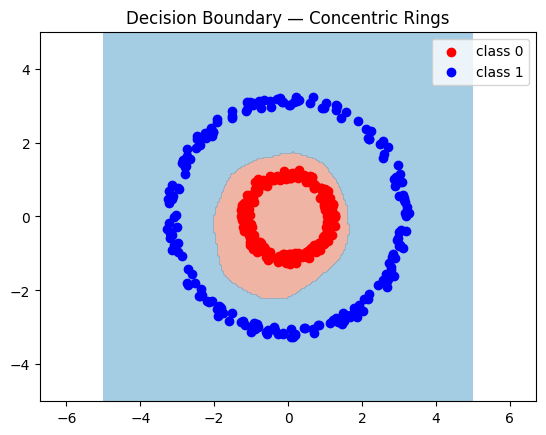

In [5]:
gx = torch.linspace(-5, 5, 200)
gy = torch.linspace(-5, 5, 200)
GX, GY = torch.meshgrid(gx, gy, indexing='ij')
grid = torch.stack([GX.flatten(), GY.flatten()], dim=1)

model.eval()
with torch.no_grad():
    pred = torch.argmax(model(grid), dim=1).reshape(200, 200).float()

plt.contourf(GX.numpy(), GY.numpy(), pred.numpy(), levels=[-0.5, 0.5, 1.5], cmap='RdBu', alpha=0.6)
plt.scatter(c0[:,0], c0[:,1], label='class 0', c='red')
plt.scatter(c1[:,0], c1[:,1], label='class 1', c='blue')
plt.axis('equal')
plt.legend()
plt.title('Decision Boundary — Concentric Rings')
plt.show()

Observation:

1. Neural networks can learn nonlinear decision boundaries — not just diagonal lines
2. The same architecture that works for linear problems works for nonlinear ones — the network discovers the structure from data
3. axis('equal') matters for circular data — always use it when x and y represent the same physical scale
4. Feature engineering (adding r²) would have made this even easier — something to try later